
# Notebook 1: Market-Wide PCA and Unsupervised Regime Clustering

This notebook investigates whether the joint behaviour of the 51 assets can be compressed into a smaller set of market-wide principal components, and whether those components separate time periods into recurring market states.

## Pipeline

1. Load `prices.txt`
2. Calculate **simple percentage returns**
3. Standardise each asset's returns
4. Fit PCA using all available components
5. Plot cumulative explained variance
6. Select the **smallest number of PCs explaining at least 98%**
7. Fit PCA again using the selected number of components
8. Compare:
   - K-means
   - Gaussian Mixture Model
   - Bayesian Gaussian Mixture Model
9. Measure whether the resulting labels are persistent through time
10. Summarise the market behaviour associated with each cluster

> This is an exploratory regime-discovery notebook. It does not yet establish that a cluster is tradable or that it can be identified without look-ahead bias.


## 1. Imports

In [1]:

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture, BayesianGaussianMixture
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)



## 2. Configuration

This is the main cell to edit.

- Leave `N_COMPONENTS_OVERRIDE = None` to automatically use \(k_{98}\).
- Set it to an integer such as `12` to use exactly 12 principal components without changing any other cell.
- `VARIANCE_TARGET = 0.98` controls the automatic variance threshold.
- The clustering algorithms test the values in `CLUSTER_COUNTS`.


In [2]:

# ---------------------------
# DATA
# ---------------------------
DATA_FILENAME = "prices.txt"

# ---------------------------
# RETURNS AND PCA
# ---------------------------
RETURN_TYPE = "simple"           # Keep as "simple" for percentage returns
VARIANCE_TARGET = 0.98           # Automatic target: k_98
N_COMPONENTS_OVERRIDE = None     # Example: set to 12 to force 12 PCs
WHITEN_PCS = False               # False preserves the natural variance of each PC

# ---------------------------
# CLUSTERING
# ---------------------------
CLUSTER_COUNTS = range(2, 7)     # Test 2, 3, 4, 5 and 6 clusters
RANDOM_STATE = 42
N_INITIALISATIONS = 50
GMM_COVARIANCE_TYPE = "diag"     # Robust when the retained PCA dimension is large
BAYESIAN_MAX_COMPONENTS = 6
BAYESIAN_WEIGHT_THRESHOLD = 0.01

# ---------------------------
# OUTPUT
# ---------------------------
SAVE_OUTPUTS = True
OUTPUT_DIRECTORY = Path("outputs") / "notebook1_market_pca"


## 3. Locate and load `prices.txt`

In [3]:

def locate_data_file(filename: str) -> Path:
    candidates = [
        Path.cwd() / filename,
        Path.cwd().parent / filename,
        Path.cwd().parent.parent / filename,
    ]

    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()

    searched = "\n".join(f"  - {path}" for path in candidates)
    raise FileNotFoundError(
        f"Could not find {filename!r}. Searched:\n{searched}\n"
        "Move the notebook beside prices.txt or inside a folder directly below it."
    )


data_path = locate_data_file(DATA_FILENAME)
print(f"Loading data from: {data_path}")

# prices.txt is whitespace-separated and contains a header row.
prices = pd.read_csv(data_path, sep=r"\s+")

# Force all columns to numeric so invalid entries fail clearly.
prices = prices.apply(pd.to_numeric, errors="raise")

print(f"Price matrix shape: {prices.shape}")
display(prices.head())


Loading data from: /Users/akhilmathur/Documents/Projects/susquehenna_algothon_TeamLynfield/prices.txt
Price matrix shape: (1000, 51)


,ALGO,AENO,LSST,SRNA,ELLT,AMRP,OTCS,HETT,HUXZ,DUCT,SMAH,NPCK,MSDP,EORC,CUBO,HRET,ANSO,DIHO,RTTH,SPLZ,NWIG,MMBT,MDGI,AGVF,RRES,CTGI,ALUT,ACAC,SRTX,GARI,RCRI,ACIX,CCNS,MTNS,IHOZ,NAYO,FWWG,EELT,HRND,AETS,ULXY,BLBT,BENI,ITPA,HTRK,NGTE,ILVX,FCSG,FARS,MHRM,EAFC
0,100.00,116.51,113.55,134.23,64.12,25.05,14.68,59.24,83.62,19.71,44.08,15.14,34.11,31.68,124.31,52.61,41.73,12.47,39.83,104.33,120.19,78.80,144.60,136.28,37.90,86.48,17.48,73.25,290.79,15.60,54.64,16.33,23.62,22.23,136.17,33.34,36.97,74.85,24.07,42.97,45.25,52.23,32.37,18.82,10.86,52.65,32.58,27.46,66.43,22.41,45.08
1,98.49,112.94,114.53,133.21,62.74,23.96,14.55,58.28,79.94,19.22,43.44,14.74,34.15,31.79,122.99,52.17,41.68,12.37,39.29,102.81,120.04,75.19,142.60,134.82,37.06,84.27,17.55,74.00,283.39,15.47,54.58,16.11,23.97,21.35,133.47,33.50,37.23,76.08,23.09,41.36,44.12,52.73,32.25,18.41,10.77,49.71,31.66,26.47,64.66,22.10,44.28
2,97.83,112.70,112.17,132.80,61.61,23.30,14.69,57.97,81.20,19.22,42.87,14.68,33.36,31.55,122.11,53.63,41.74,12.63,39.44,101.34,116.39,69.78,136.02,134.65,36.64,85.52,17.59,71.84,279.44,15.84,53.81,16.26,24.17,21.69,133.36,32.64,37.53,76.36,22.96,39.87,45.66,53.23,32.23,18.22,10.69,50.53,30.84,25.28,64.19,20.87,45.30
3,98.02,112.26,116.09,133.16,63.55,23.47,14.43,57.02,81.82,19.39,43.37,14.87,32.96,30.92,120.21,53.80,41.83,12.76,38.80,100.05,117.31,73.62,133.85,134.33,36.44,89.13,17.23,72.40,276.45,15.65,54.36,15.86,23.87,21.42,134.19,32.24,38.05,80.89,23.37,41.29,45.71,52.67,32.20,18.22,10.28,51.64,30.95,24.60,62.80,20.95,46.32
4,99.13,113.59,119.58,137.20,63.64,23.61,14.61,58.78,83.01,19.91,43.64,14.92,34.12,30.97,118.87,54.14,41.77,12.63,38.82,105.26,117.15,73.46,134.42,136.34,36.83,89.09,17.49,74.57,280.34,16.29,54.65,15.92,24.16,21.87,139.10,31.65,37.44,80.64,23.07,41.49,47.14,53.59,32.33,18.25,10.50,53.57,31.49,25.66,63.94,20.72,45.56


## 4. Validate the price data

In [4]:

def validate_prices(price_frame: pd.DataFrame) -> None:
    if price_frame.empty:
        raise ValueError("The price dataframe is empty.")

    if price_frame.shape[1] < 2:
        raise ValueError("Expected multiple asset columns.")

    if price_frame.columns.duplicated().any():
        duplicates = price_frame.columns[price_frame.columns.duplicated()].tolist()
        raise ValueError(f"Duplicate asset columns found: {duplicates}")

    if price_frame.isna().any().any():
        missing = int(price_frame.isna().sum().sum())
        raise ValueError(f"Found {missing} missing price values.")

    if not np.isfinite(price_frame.to_numpy()).all():
        raise ValueError("Found infinite or non-finite price values.")

    if (price_frame <= 0).any().any():
        non_positive = int((price_frame <= 0).sum().sum())
        raise ValueError(
            f"Found {non_positive} non-positive prices. "
            "Percentage returns require strictly positive price levels."
        )


validate_prices(prices)

print(f"Observations: {prices.shape[0]}")
print(f"Assets:       {prices.shape[1]}")
print("Price data passed validation.")


Observations: 1000
Assets:       51
Price data passed validation.



## 5. Calculate simple percentage returns

For asset \(i\), the one-period simple return is

\[
r_{i,t} = \frac{P_{i,t}}{P_{i,t-1}} - 1.
\]

The first price row has no previous period, so it is removed.


In [5]:

if RETURN_TYPE != "simple":
    raise ValueError("This notebook is currently configured for RETURN_TYPE='simple'.")

returns = prices.pct_change(fill_method=None).dropna(how="any")

if returns.empty:
    raise ValueError("No returns remained after percentage-change calculation.")

if not np.isfinite(returns.to_numpy()).all():
    raise ValueError("Returns contain infinite or non-finite values.")

returns.index.name = "time"

print(f"Return matrix shape: {returns.shape}")
display(returns.head())


Return matrix shape: (999, 51)


,ALGO,AENO,LSST,SRNA,ELLT,AMRP,OTCS,HETT,HUXZ,DUCT,SMAH,NPCK,MSDP,EORC,CUBO,HRET,ANSO,DIHO,RTTH,SPLZ,NWIG,MMBT,MDGI,AGVF,RRES,CTGI,ALUT,ACAC,SRTX,GARI,RCRI,ACIX,CCNS,MTNS,IHOZ,NAYO,FWWG,EELT,HRND,AETS,ULXY,BLBT,BENI,ITPA,HTRK,NGTE,ILVX,FCSG,FARS,MHRM,EAFC
time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,-0.015100,-0.030641,0.008631,-0.007599,-0.021522,-0.043513,-0.008856,-0.016205,-0.044009,-0.024860,-0.014519,-0.026420,0.001173,0.003472,-0.010619,-0.008363,-0.001198,-0.008019,-0.013558,-0.014569,-0.001248,-0.045812,-0.013831,-0.010713,-0.022164,-0.025555,0.004005,0.010239,-0.025448,-0.008333,-0.001098,-0.013472,0.014818,-0.039586,-0.019828,0.004799,0.007033,0.016433,-0.040715,-0.037468,-0.024972,0.009573,-0.003707,-0.021785,-0.008287,-0.055840,-0.028238,-0.036052,-0.026645,-0.013833,-0.017746
2,-0.006701,-0.002125,-0.020606,-0.003078,-0.018011,-0.027546,0.009622,-0.005319,0.015762,0.000000,-0.013122,-0.004071,-0.023133,-0.007550,-0.007155,0.027985,0.001440,0.021019,0.003818,-0.014298,-0.030407,-0.071951,-0.046143,-0.001261,-0.011333,0.014833,0.002279,-0.029189,-0.013938,0.023917,-0.014108,0.009311,0.008344,0.015925,-0.000824,-0.025672,0.008058,0.003680,-0.005630,-0.036025,0.034905,0.009482,-0.000620,-0.010320,-0.007428,0.016496,-0.025900,-0.044957,-0.007269,-0.055656,0.023035
3,0.001942,-0.003904,0.034947,0.002711,0.031488,0.007296,-0.017699,-0.016388,0.007635,0.008845,0.011663,0.012943,-0.011990,-0.019968,-0.015560,0.003170,0.002156,0.010293,-0.016227,-0.012729,0.007904,0.055030,-0.015954,-0.002377,-0.005459,0.042212,-0.020466,0.007795,-0.010700,-0.011995,0.010221,-0.024600,-0.012412,-0.012448,0.006224,-0.012255,0.013856,0.059324,0.017857,0.035616,0.001095,-0.010520,-0.000931,0.000000,-0.038354,0.021967,0.003567,-0.026899,-0.021654,0.003833,0.022517
4,0.011324,0.011847,0.030063,0.030339,0.001416,0.005965,0.012474,0.030866,0.014544,0.026818,0.006226,0.003362,0.035194,0.001617,-0.011147,0.006320,-0.001434,-0.010188,0.000515,0.052074,-0.001364,-0.002173,0.004258,0.014963,0.010703,-0.000449,0.015090,0.029972,0.014071,0.040895,0.005335,0.003783,0.012149,0.021008,0.036590,-0.018300,-0.016032,-0.003091,-0.012837,0.004844,0.031284,0.017467,0.004037,0.001647,0.021401,0.037374,0.017447,0.043089,0.018153,-0.010979,-0.016408
5,-0.004842,-0.023241,-0.012795,-0.002624,-0.008485,-0.032613,-0.027379,-0.019394,0.000241,-0.019086,0.013978,-0.008713,-0.031067,0.013562,-0.039371,-0.037865,0.013886,0.004751,0.007213,0.028976,-0.011694,-0.044514,-0.000074,-0.013349,-0.004073,-0.000898,0.034877,-0.010594,0.018050,-0.007366,-0.011528,0.001256,-0.012003,0.027892,0.000503,-0.000632,-0.006410,-0.011905,0.005202,0.024102,-0.040518,0.013995,-0.012372,-0.008219,0.005714,0.017360,-0.003493,-0.016758,-0.002502,-0.013031,0.018876


## 6. Quick return summary

In [6]:

return_summary = pd.DataFrame({
    "mean_return": returns.mean(),
    "std_return": returns.std(ddof=1),
    "minimum_return": returns.min(),
    "maximum_return": returns.max(),
}).sort_values("std_return", ascending=False)

display(return_summary)


,mean_return,std_return,minimum_return,maximum_return
MMBT,0.003117,0.041599,-0.123689,0.146022
RCRI,-0.000069,0.033994,-0.095130,0.106545
EELT,0.000630,0.033848,-0.106694,0.114938
AETS,0.000306,0.032977,-0.086727,0.125504
RTTH,-0.000124,0.032457,-0.090950,0.112376
NAYO,-0.000170,0.031950,-0.107002,0.110265
CTGI,0.000437,0.030104,-0.098129,0.092029
ULXY,0.000770,0.029223,-0.084140,0.112779
HRND,0.000490,0.028559,-0.098242,0.085360
AMRP,-0.000189,0.027590,-0.084191,0.087575



## 7. Standardise each asset

PCA is fitted to standardised returns so that a naturally volatile asset does not dominate purely because its return scale is larger.

For each asset,

\[
z_{i,t} = \frac{r_{i,t}-\bar r_i}{s_i}.
\]


In [7]:

scaler = StandardScaler()
scaled_returns_array = scaler.fit_transform(returns)

scaled_returns = pd.DataFrame(
    scaled_returns_array,
    index=returns.index,
    columns=returns.columns,
)

standardisation_check = pd.DataFrame({
    "mean_after_scaling": scaled_returns.mean(),
    "std_after_scaling": scaled_returns.std(ddof=0),
})

display(standardisation_check.head())


,mean_after_scaling,std_after_scaling
ALGO,-7.112540e-18,1.0
AENO,-7.112540e-18,1.0
LSST,3.556270e-18,1.0
SRNA,-3.556270e-18,1.0
ELLT,-3.556270e-18,1.0


## 8. Fit full PCA and calculate explained variance

In [8]:

full_pca = PCA(whiten=False)
full_pca.fit(scaled_returns)

explained_variance_ratio = full_pca.explained_variance_ratio_
cumulative_explained_variance = np.cumsum(explained_variance_ratio)
component_numbers = np.arange(1, len(explained_variance_ratio) + 1)

def minimum_components_for_threshold(cumulative_variance, threshold: float) -> int:
    if not 0 < threshold <= 1:
        raise ValueError("The variance threshold must lie in (0, 1].")
    return int(np.searchsorted(cumulative_variance, threshold, side="left") + 1)

k_90 = minimum_components_for_threshold(cumulative_explained_variance, 0.90)
k_95 = minimum_components_for_threshold(cumulative_explained_variance, 0.95)
k_98 = minimum_components_for_threshold(cumulative_explained_variance, 0.98)

variance_table = pd.DataFrame({
    "number_of_components": component_numbers,
    "individual_explained_variance": explained_variance_ratio,
    "cumulative_explained_variance": cumulative_explained_variance,
})

print(f"Minimum PCs for 90% variance: {k_90}")
print(f"Minimum PCs for 95% variance: {k_95}")
print(f"Minimum PCs for 98% variance: {k_98}")
display(variance_table)


Minimum PCs for 90% variance: 40
Minimum PCs for 95% variance: 45
Minimum PCs for 98% variance: 48


,number_of_components,individual_explained_variance,cumulative_explained_variance
0,1,0.233018,0.233018
1,2,0.054083,0.287100
2,3,0.038126,0.325226
3,4,0.023618,0.348844
4,5,0.023149,0.371992
5,6,0.020691,0.392683
6,7,0.020438,0.413121
7,8,0.019799,0.432920
8,9,0.019373,0.452293
9,10,0.018871,0.471164



## 9. Explained variance graph

This graph shows how much total variance is retained as more principal components are included.

The vertical line marks \(k_{98}\), the smallest number of PCs that reaches 98%.


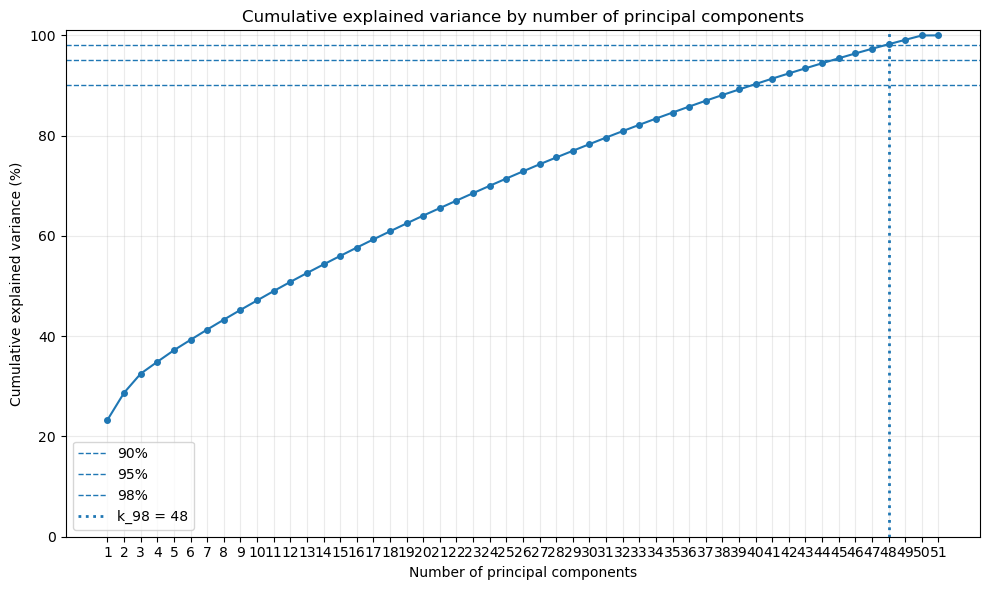

In [9]:

plt.figure(figsize=(10, 6))
plt.plot(
    component_numbers,
    cumulative_explained_variance * 100,
    marker="o",
    markersize=4,
)
plt.axhline(90, linestyle="--", linewidth=1, label="90%")
plt.axhline(95, linestyle="--", linewidth=1, label="95%")
plt.axhline(98, linestyle="--", linewidth=1, label="98%")
plt.axvline(k_98, linestyle=":", linewidth=2, label=f"k_98 = {k_98}")

plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance (%)")
plt.title("Cumulative explained variance by number of principal components")
plt.xticks(component_numbers)
plt.ylim(0, 101)
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()



## 10. Choose the number of PCs used by the rest of the notebook

By default:

```python
N_COMPONENTS_OVERRIDE = None
```

so the notebook uses \(k_{98}\).

To try exactly 12 PCs later, change only the configuration cell to:

```python
N_COMPONENTS_OVERRIDE = 12
```

and rerun the notebook.


In [10]:

if N_COMPONENTS_OVERRIDE is None:
    N_COMPONENTS = k_98
    selection_rule = f"automatic: minimum PCs explaining {VARIANCE_TARGET:.0%}"
else:
    N_COMPONENTS = int(N_COMPONENTS_OVERRIDE)
    selection_rule = "manual override"

max_components = min(scaled_returns.shape)

if not 1 <= N_COMPONENTS <= max_components:
    raise ValueError(
        f"N_COMPONENTS must be between 1 and {max_components}, "
        f"but received {N_COMPONENTS}."
    )

variance_retained = cumulative_explained_variance[N_COMPONENTS - 1]

print(f"PCA selection rule: {selection_rule}")
print(f"PCs used below:      {N_COMPONENTS}")
print(f"Variance retained:   {variance_retained:.4%}")


PCA selection rule: automatic: minimum PCs explaining 98%
PCs used below:      48
Variance retained:   98.2236%


## 11. Fit the selected PCA representation

In [11]:

pca = PCA(
    n_components=N_COMPONENTS,
    whiten=WHITEN_PCS,
    random_state=RANDOM_STATE,
)

pca_scores_array = pca.fit_transform(scaled_returns)

pc_names = [f"PC{i}" for i in range(1, N_COMPONENTS + 1)]

pca_scores = pd.DataFrame(
    pca_scores_array,
    index=returns.index,
    columns=pc_names,
)

print(f"Original return dimension: {scaled_returns.shape[1]}")
print(f"PCA dimension used:        {pca_scores.shape[1]}")
print(f"PCA score matrix shape:    {pca_scores.shape}")
display(pca_scores.head())


Original return dimension: 51
PCA dimension used:        48
PCA score matrix shape:    (999, 48)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20,PC21,PC22,PC23,PC24,PC25,PC26,PC27,PC28,PC29,PC30,PC31,PC32,PC33,PC34,PC35,PC36,PC37,PC38,PC39,PC40,PC41,PC42,PC43,PC44,PC45,PC46,PC47,PC48
time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,-5.231623,0.722882,0.023453,0.775642,0.595163,0.938829,-0.176692,-1.442422,1.454957,0.597881,-0.070658,0.764744,0.461867,0.958642,-0.635772,0.303290,-0.710567,-1.413354,-0.766308,-0.872691,-0.885441,0.127505,0.682975,0.279347,0.166103,-0.470342,-0.217578,0.832100,0.302434,-1.582759,-0.477006,-0.388513,1.051080,-1.292347,0.845994,0.042697,-0.208883,0.345107,-0.667485,1.102963,0.833864,-0.500860,0.098753,-0.707807,-0.879177,0.350072,-0.514114,0.325812
2,-2.083480,-0.667298,-0.140861,3.049877,0.463232,0.026963,-0.235721,-0.259113,0.862894,-1.206558,-0.816740,-0.175812,-1.052769,-1.213669,0.344987,-0.338236,1.364900,0.139843,0.023100,0.204168,-0.021715,0.244913,-1.230779,0.428596,-0.735349,-0.110710,0.232448,-0.971332,-0.067047,-1.212798,-0.300302,-1.075438,0.205920,0.368077,1.082375,0.879905,-0.451005,0.792982,-1.353286,1.070945,-0.172771,1.794503,0.441929,-1.120549,2.147535,0.066066,0.772738,0.400110
3,-0.086843,0.336493,1.122838,-0.670022,0.574599,-0.402515,1.328108,-0.085383,-0.725319,-0.101393,-0.442506,-1.309604,0.959228,0.257247,0.527763,-0.331539,1.007322,-1.519220,1.909958,0.095533,-1.010850,1.096199,0.742667,0.680946,-1.159688,-0.692650,0.837888,-0.553761,-0.711835,-0.935795,0.543085,-1.248020,-0.345443,1.027821,-0.421855,-1.142087,0.288814,0.135018,-0.946040,-2.209202,0.168249,0.635501,0.725869,0.358835,-0.815001,-0.394862,0.456245,-0.917140
4,4.353145,-1.234685,-0.632838,0.744573,0.379867,0.528612,-0.223090,-0.159083,0.149893,-0.854473,1.594846,-1.177776,-0.340984,-0.228612,-0.350142,-1.117609,-0.622841,1.867883,-0.881284,0.626891,1.071861,0.400053,0.272097,-2.044251,-0.857887,-0.936738,-0.044273,0.729101,-1.349237,0.748321,-0.193381,0.462888,-0.394586,-0.572410,0.409295,-1.201900,-0.519156,0.977954,0.934199,0.779726,-0.166334,-0.048243,-0.636943,-0.575301,-0.053740,-0.180452,-0.673540,-0.528383
5,-1.726997,1.030345,-1.211252,-1.136840,0.470972,0.382472,-0.789372,-0.228922,0.322976,-0.977961,-0.210881,0.052789,-0.772939,0.049697,-1.135523,0.729745,1.180091,0.374278,0.518640,0.284446,0.961710,0.832595,0.492329,-0.905030,-0.235648,0.277458,0.577860,0.200825,0.664792,1.059478,-1.230086,-1.006888,-0.728431,-0.711059,0.720388,0.278212,-0.808163,2.813685,-0.816283,0.079428,-0.104925,0.899096,0.176835,1.040842,0.333591,-0.645359,0.734097,1.769531


## 12. Inspect PCA loadings

In [12]:

loadings = pd.DataFrame(
    pca.components_.T,
    index=returns.columns,
    columns=pc_names,
)

n_components_to_display = min(5, N_COMPONENTS)
display(loadings.iloc[:, :n_components_to_display])

for component in pc_names[:n_components_to_display]:
    ordered = loadings[component].sort_values()
    top_negative = ordered.head(5)
    top_positive = ordered.tail(5).sort_values(ascending=False)

    print(f"\n{component}")
    print("Largest positive loadings:")
    display(top_positive.to_frame("loading"))

    print("Largest negative loadings:")
    display(top_negative.to_frame("loading"))


,PC1,PC2,PC3,PC4,PC5
ALGO,0.278072,0.078969,0.119457,-0.033581,0.026002
AENO,0.143143,-0.146817,0.000822,-0.142871,-0.143468
LSST,0.139007,-0.129467,0.003535,0.002126,0.007531
SRNA,0.165010,-0.143204,0.026503,0.204000,0.046733
ELLT,0.134936,0.124412,-0.087365,0.029355,-0.267585
AMRP,0.145295,-0.099580,0.000666,-0.187048,-0.190944
OTCS,0.109894,-0.108931,0.029562,0.153612,0.101388
HETT,0.147371,-0.111034,0.021680,0.180397,-0.069138
HUXZ,0.144853,-0.092097,0.012519,-0.143420,-0.003240
DUCT,0.153908,-0.087410,-0.042143,0.126643,0.143826



PC1
Largest positive loadings:


,loading
ALGO,0.278072
ILVX,0.195220
BENI,0.178460
CUBO,0.171573
BLBT,0.166458


Largest negative loadings:


,loading
RTTH,0.086389
MMBT,0.091808
NAYO,0.096588
CTGI,0.101246
AETS,0.105723


...

,loading
EAFC,-0.264246
MHRM,-0.241196
HRND,-0.218514
ACAC,-0.214514
AMRP,-0.187048



PC5
Largest positive loadings:


,loading
MSDP,0.381243
EAFC,0.325180
SPLZ,0.319180
AETS,0.239554
MHRM,0.183444


Largest negative loadings:


,loading
ELLT,-0.267585
HRND,-0.247776
MDGI,-0.218096
GARI,-0.199419
ACIX,-0.196891


## 13. Plot the first few principal components through time

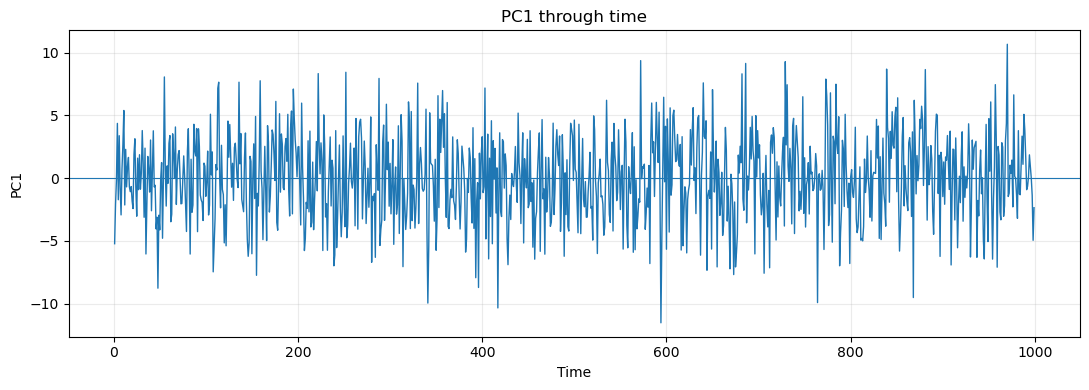

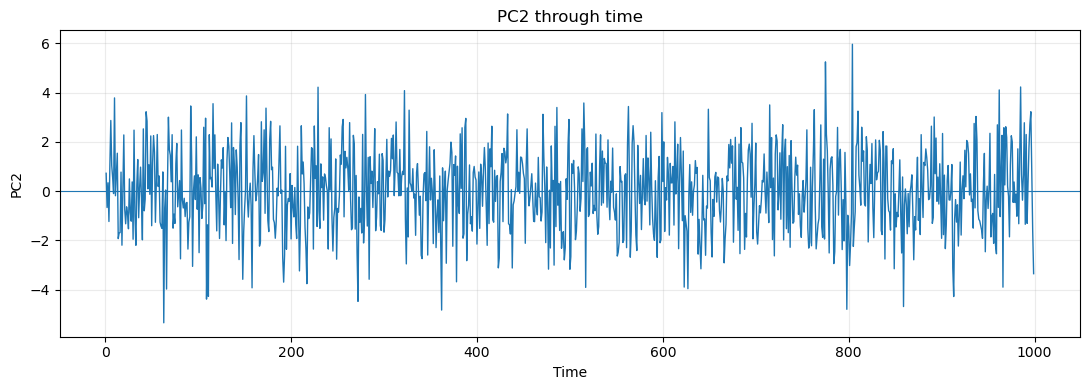

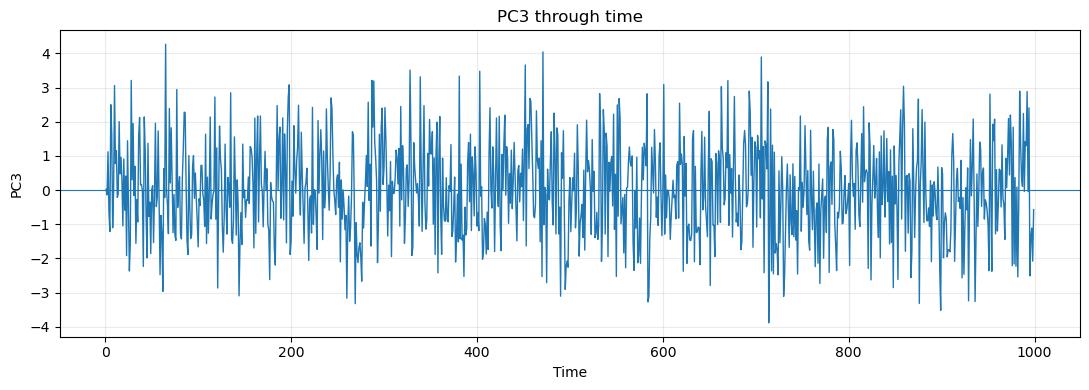

In [13]:

for component in pc_names[: min(3, N_COMPONENTS)]:
    plt.figure(figsize=(11, 4))
    plt.plot(pca_scores.index, pca_scores[component], linewidth=1)
    plt.axhline(0, linewidth=0.8)
    plt.xlabel("Time")
    plt.ylabel(component)
    plt.title(f"{component} through time")
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


## 14. Plot PC1 against PC2

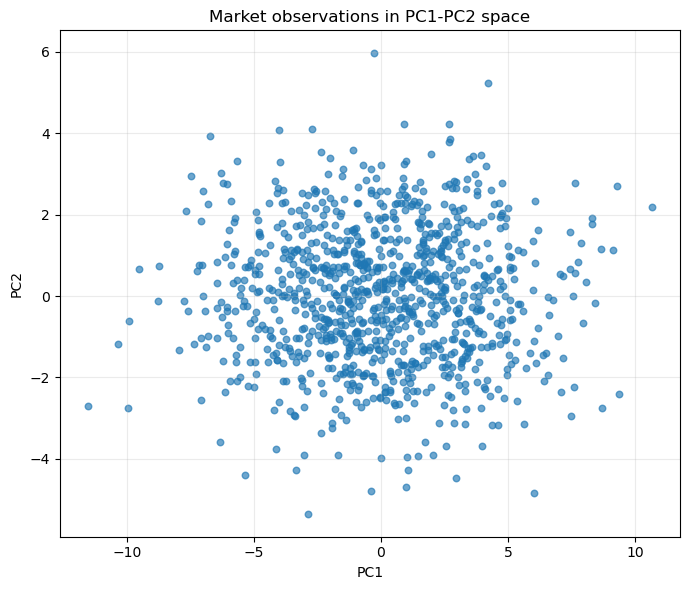

In [14]:

if N_COMPONENTS >= 2:
    plt.figure(figsize=(7, 6))
    plt.scatter(
        pca_scores["PC1"],
        pca_scores["PC2"],
        s=22,
        alpha=0.65,
    )
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("Market observations in PC1-PC2 space")
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()
else:
    print("At least two principal components are required for the PC1-PC2 plot.")



# Part B: Unsupervised regime clustering

The following models cluster each time period using all retained PCA scores.

- **K-means:** distance-based hard clusters.
- **Gaussian Mixture Model:** probabilistic clusters with a Gaussian distribution for each state.
- **Bayesian Gaussian Mixture Model:** begins with a maximum number of components and can assign very small weights to unnecessary components.

These models do not understand time order. Persistence is checked separately afterward.


## 15. Helper functions

In [15]:

def clustering_quality_metrics(features: np.ndarray, labels: np.ndarray) -> dict:
    unique_labels = np.unique(labels)

    if len(unique_labels) < 2 or len(unique_labels) >= len(labels):
        return {
            "silhouette": np.nan,
            "calinski_harabasz": np.nan,
            "davies_bouldin": np.nan,
        }

    return {
        "silhouette": silhouette_score(features, labels),
        "calinski_harabasz": calinski_harabasz_score(features, labels),
        "davies_bouldin": davies_bouldin_score(features, labels),
    }


def consecutive_run_lengths(labels: np.ndarray) -> np.ndarray:
    labels = np.asarray(labels)

    if labels.size == 0:
        return np.array([], dtype=int)

    change_locations = np.flatnonzero(labels[1:] != labels[:-1]) + 1
    boundaries = np.concatenate(([0], change_locations, [labels.size]))
    return np.diff(boundaries)


def persistence_metrics(labels: np.ndarray) -> dict:
    labels = np.asarray(labels)
    run_lengths = consecutive_run_lengths(labels)

    switches = int(np.sum(labels[1:] != labels[:-1]))
    isolated_fraction = float(np.mean(run_lengths == 1)) if run_lengths.size else np.nan

    return {
        "number_of_states_used": int(np.unique(labels).size),
        "number_of_switches": switches,
        "mean_run_length": float(np.mean(run_lengths)),
        "median_run_length": float(np.median(run_lengths)),
        "maximum_run_length": int(np.max(run_lengths)),
        "isolated_run_fraction": isolated_fraction,
    }


def relabel_by_cluster_mean(labels: np.ndarray, reference_series: pd.Series) -> np.ndarray:
    '''
    Relabel clusters from lowest to highest average reference value.
    This makes plots easier to compare, but does not change membership.
    '''
    temporary = pd.DataFrame({
        "label": labels,
        "reference": reference_series.to_numpy(),
    })

    ordered_old_labels = (
        temporary.groupby("label")["reference"]
        .mean()
        .sort_values()
        .index
        .tolist()
    )

    mapping = {old: new for new, old in enumerate(ordered_old_labels)}
    return np.array([mapping[label] for label in labels], dtype=int)


## 16. Compare K-means cluster counts

In [16]:

X_cluster = pca_scores.to_numpy()

kmeans_models = {}
kmeans_results = []

for n_clusters in CLUSTER_COUNTS:
    model = KMeans(
        n_clusters=n_clusters,
        random_state=RANDOM_STATE,
        n_init=N_INITIALISATIONS,
    )
    raw_labels = model.fit_predict(X_cluster)
    labels = relabel_by_cluster_mean(raw_labels, pca_scores["PC1"])

    quality = clustering_quality_metrics(X_cluster, labels)
    persistence = persistence_metrics(labels)

    kmeans_models[n_clusters] = {
        "model": model,
        "labels": labels,
    }

    kmeans_results.append({
        "model": "KMeans",
        "n_clusters": n_clusters,
        "inertia": model.inertia_,
        **quality,
        **persistence,
    })

kmeans_results = pd.DataFrame(kmeans_results)
display(kmeans_results)


,model,n_clusters,inertia,silhouette,calinski_harabasz,davies_bouldin,number_of_states_used,number_of_switches,mean_run_length,median_run_length,maximum_run_length,isolated_run_fraction
0,KMeans,2,42354.072727,0.128844,181.016334,2.329816,2,472,2.112051,2.0,9,0.427061
1,KMeans,3,40317.130964,0.070242,120.145989,2.971406,3,641,1.556075,1.0,8,0.668224
2,KMeans,4,39304.083316,0.052503,90.627893,3.498366,4,720,1.385576,1.0,8,0.725381
3,KMeans,5,38532.981154,0.044578,74.234293,3.584702,5,786,1.269377,1.0,5,0.794155
4,KMeans,6,37971.727954,0.042253,63.140071,3.732284,6,818,1.219780,1.0,4,0.818071


## 17. Select and plot the best K-means model

Best K-means cluster count by silhouette score: 2


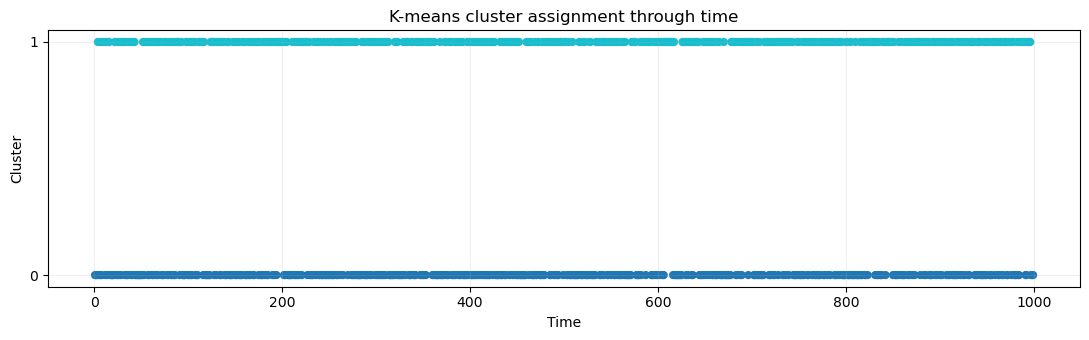

In [17]:

best_kmeans_k = int(
    kmeans_results.loc[kmeans_results["silhouette"].idxmax(), "n_clusters"]
)

kmeans_labels = kmeans_models[best_kmeans_k]["labels"]
pca_scores["KMeans_regime"] = kmeans_labels

print(f"Best K-means cluster count by silhouette score: {best_kmeans_k}")

plt.figure(figsize=(11, 3.5))
plt.scatter(
    pca_scores.index,
    pca_scores["KMeans_regime"],
    c=pca_scores["KMeans_regime"],
    s=24,
    cmap="tab10",
)
plt.yticks(range(best_kmeans_k))
plt.xlabel("Time")
plt.ylabel("Cluster")
plt.title("K-means cluster assignment through time")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


## 18. Compare Gaussian Mixture Model cluster counts

In [18]:

gmm_models = {}
gmm_results = []

for n_clusters in CLUSTER_COUNTS:
    model = GaussianMixture(
        n_components=n_clusters,
        covariance_type=GMM_COVARIANCE_TYPE,
        n_init=10,
        max_iter=1000,
        reg_covar=1e-6,
        random_state=RANDOM_STATE,
    )
    raw_labels = model.fit_predict(X_cluster)
    labels = relabel_by_cluster_mean(raw_labels, pca_scores["PC1"])

    quality = clustering_quality_metrics(X_cluster, labels)
    persistence = persistence_metrics(labels)

    gmm_models[n_clusters] = {
        "model": model,
        "labels": labels,
    }

    gmm_results.append({
        "model": "GaussianMixture",
        "n_clusters": n_clusters,
        "bic": model.bic(X_cluster),
        "aic": model.aic(X_cluster),
        **quality,
        **persistence,
    })

gmm_results = pd.DataFrame(gmm_results)
display(gmm_results)


,model,n_clusters,bic,aic,silhouette,calinski_harabasz,davies_bouldin,number_of_states_used,number_of_switches,mean_run_length,median_run_length,maximum_run_length,isolated_run_fraction
0,GaussianMixture,2,126849.192985,125902.189312,0.119073,166.696765,2.418359,2,482,2.068323,2.0,11,0.445135
1,GaussianMixture,3,127425.663275,126002.704389,0.061372,110.667729,3.066040,3,616,1.619125,1.0,9,0.645057
2,GaussianMixture,4,127840.576645,125941.662546,-0.008919,29.443207,6.550025,4,641,1.556075,1.0,12,0.686916
3,GaussianMixture,5,128342.729679,125967.860366,-0.018275,40.384342,5.887489,5,652,1.529862,1.0,8,0.693721
4,GaussianMixture,6,128874.578356,126023.753830,-0.016509,32.797252,6.377377,6,764,1.305882,1.0,5,0.773856


## 19. Select and plot the best Gaussian Mixture Model

Best GMM cluster count by minimum BIC: 2
Average maximum GMM assignment probability: 0.822


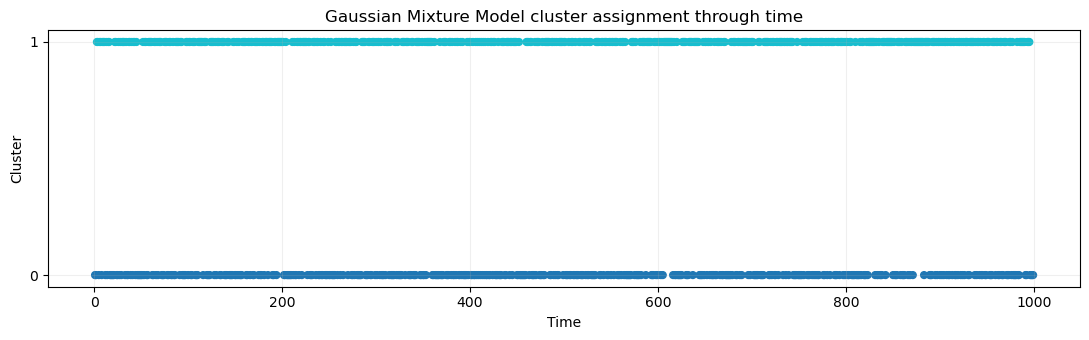

In [19]:

best_gmm_k = int(
    gmm_results.loc[gmm_results["bic"].idxmin(), "n_clusters"]
)

best_gmm = gmm_models[best_gmm_k]["model"]
gmm_labels = gmm_models[best_gmm_k]["labels"]
gmm_probabilities = best_gmm.predict_proba(X_cluster)

pca_scores["GMM_regime"] = gmm_labels
pca_scores["GMM_max_probability"] = gmm_probabilities.max(axis=1)

print(f"Best GMM cluster count by minimum BIC: {best_gmm_k}")
print(
    "Average maximum GMM assignment probability: "
    f"{pca_scores['GMM_max_probability'].mean():.3f}"
)

plt.figure(figsize=(11, 3.5))
plt.scatter(
    pca_scores.index,
    pca_scores["GMM_regime"],
    c=pca_scores["GMM_regime"],
    s=24,
    cmap="tab10",
)
plt.yticks(range(best_gmm_k))
plt.xlabel("Time")
plt.ylabel("Cluster")
plt.title("Gaussian Mixture Model cluster assignment through time")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


## 20. Fit a Bayesian Gaussian Mixture Model

In [20]:

bayesian_gmm = BayesianGaussianMixture(
    n_components=BAYESIAN_MAX_COMPONENTS,
    covariance_type=GMM_COVARIANCE_TYPE,
    weight_concentration_prior_type="dirichlet_process",
    n_init=10,
    max_iter=2000,
    reg_covar=1e-6,
    random_state=RANDOM_STATE,
)

raw_bayesian_labels = bayesian_gmm.fit_predict(X_cluster)
bayesian_labels = relabel_by_cluster_mean(
    raw_bayesian_labels,
    pca_scores["PC1"],
)

bayesian_probabilities = bayesian_gmm.predict_proba(X_cluster)
effective_components = int(
    np.sum(bayesian_gmm.weights_ > BAYESIAN_WEIGHT_THRESHOLD)
)

pca_scores["BayesianGMM_regime"] = bayesian_labels
pca_scores["BayesianGMM_max_probability"] = bayesian_probabilities.max(axis=1)

bayesian_quality = clustering_quality_metrics(X_cluster, bayesian_labels)
bayesian_persistence = persistence_metrics(bayesian_labels)

bayesian_summary = pd.DataFrame([{
    "model": "BayesianGaussianMixture",
    "maximum_components": BAYESIAN_MAX_COMPONENTS,
    "effective_components_by_weight": effective_components,
    "average_max_probability": pca_scores["BayesianGMM_max_probability"].mean(),
    **bayesian_quality,
    **bayesian_persistence,
}])

display(bayesian_summary)

weights_table = pd.DataFrame({
    "original_component": np.arange(BAYESIAN_MAX_COMPONENTS),
    "mixture_weight": bayesian_gmm.weights_,
}).sort_values("mixture_weight", ascending=False)

display(weights_table)


,model,maximum_components,effective_components_by_weight,average_max_probability,silhouette,calinski_harabasz,davies_bouldin,number_of_states_used,number_of_switches,mean_run_length,median_run_length,maximum_run_length,isolated_run_fraction
0,BayesianGaussianMixture,6,1,1.0,NaN,NaN,NaN,1,0,999.0,999.0,999,0.0


,original_component,mixture_weight
0,0,9.998334e-01
1,1,1.428333e-04
2,2,2.040476e-05
3,3,2.914966e-06
4,4,4.164237e-07
5,5,5.948910e-08


## 21. Plot Bayesian GMM labels through time

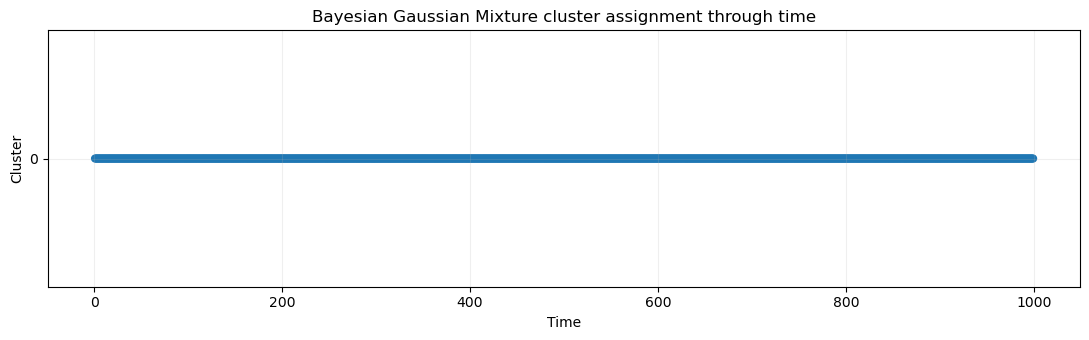

In [21]:

n_bayesian_labels = pca_scores["BayesianGMM_regime"].nunique()

plt.figure(figsize=(11, 3.5))
plt.scatter(
    pca_scores.index,
    pca_scores["BayesianGMM_regime"],
    c=pca_scores["BayesianGMM_regime"],
    s=24,
    cmap="tab10",
)
plt.yticks(range(n_bayesian_labels))
plt.xlabel("Time")
plt.ylabel("Cluster")
plt.title("Bayesian Gaussian Mixture cluster assignment through time")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


## 22. Compare the selected models

In [22]:

selected_model_comparison = pd.DataFrame([
    {
        "model": f"KMeans (k={best_kmeans_k})",
        **clustering_quality_metrics(X_cluster, kmeans_labels),
        **persistence_metrics(kmeans_labels),
    },
    {
        "model": f"GaussianMixture (k={best_gmm_k})",
        **clustering_quality_metrics(X_cluster, gmm_labels),
        **persistence_metrics(gmm_labels),
    },
    {
        "model": (
            "BayesianGaussianMixture "
            f"(used={np.unique(bayesian_labels).size}, "
            f"weight-effective={effective_components})"
        ),
        **clustering_quality_metrics(X_cluster, bayesian_labels),
        **persistence_metrics(bayesian_labels),
    },
])

display(selected_model_comparison)


,model,silhouette,calinski_harabasz,davies_bouldin,number_of_states_used,number_of_switches,mean_run_length,median_run_length,maximum_run_length,isolated_run_fraction
0,KMeans (k=2),0.128844,181.016334,2.329816,2,472,2.112051,2.0,9,0.427061
1,GaussianMixture (k=2),0.119073,166.696765,2.418359,2,482,2.068323,2.0,11,0.445135
2,"BayesianGaussianMixture (used=1, weight-effect...",NaN,NaN,NaN,1,0,999.000000,999.0,999,0.000000



## 23. Add basic market features for interpreting the clusters

These features are not used to fit the clustering models. They are calculated afterward to help describe what each cluster represents.

- `market_return`: equal-weighted mean return across all assets
- `average_absolute_return`: average absolute movement across assets
- `cross_sectional_dispersion`: standard deviation of asset returns at each time
- `positive_asset_fraction`: fraction of assets with a positive return
- `next_market_return`: next-period equal-weighted market return

`next_market_return` is included only for exploration. It must not be used as an input when forming a cluster at the current time.


In [23]:

market_features = pd.DataFrame(index=returns.index)

market_features["market_return"] = returns.mean(axis=1)
market_features["average_absolute_return"] = returns.abs().mean(axis=1)
market_features["cross_sectional_dispersion"] = returns.std(axis=1, ddof=1)
market_features["positive_asset_fraction"] = (returns > 0).mean(axis=1)
market_features["next_market_return"] = market_features["market_return"].shift(-1)

for column in [
    "KMeans_regime",
    "GMM_regime",
    "BayesianGMM_regime",
    "GMM_max_probability",
    "BayesianGMM_max_probability",
]:
    market_features[column] = pca_scores[column]

display(market_features.head())


,market_return,average_absolute_return,cross_sectional_dispersion,positive_asset_fraction,next_market_return,KMeans_regime,GMM_regime,BayesianGMM_regime,GMM_max_probability,BayesianGMM_max_probability
time,,,,,,,,,,
1,-0.015133,0.018277,0.016910,0.196078,-0.006695,0,0,0,0.973898,1.0
2,-0.006695,0.016495,0.021412,0.352941,0.002012,0,0,0,0.729134,1.0
3,0.002012,0.015404,0.020317,0.529412,0.011414,0,1,0,0.665514,1.0
4,0.011414,0.015508,0.016707,0.764706,-0.004882,1,1,0,0.963273,1.0
5,-0.004882,0.014703,0.018300,0.352941,0.012578,0,0,0,0.905177,1.0


## 24. Summarise each selected model's clusters

In [24]:

def regime_summary(frame: pd.DataFrame, label_column: str) -> pd.DataFrame:
    summary = (
        frame.groupby(label_column)
        .agg(
            observations=("market_return", "size"),
            mean_market_return=("market_return", "mean"),
            market_volatility=("market_return", "std"),
            mean_absolute_return=("average_absolute_return", "mean"),
            mean_dispersion=("cross_sectional_dispersion", "mean"),
            mean_positive_asset_fraction=("positive_asset_fraction", "mean"),
            mean_next_market_return=("next_market_return", "mean"),
        )
    )

    summary["sample_fraction"] = (
        summary["observations"] / summary["observations"].sum()
    )

    return summary


print("K-means cluster summary")
display(regime_summary(market_features, "KMeans_regime"))

print("Gaussian Mixture cluster summary")
display(regime_summary(market_features, "GMM_regime"))

print("Bayesian Gaussian Mixture cluster summary")
display(regime_summary(market_features, "BayesianGMM_regime"))


K-means cluster summary


,observations,mean_market_return,market_volatility,mean_absolute_return,mean_dispersion,mean_positive_asset_fraction,mean_next_market_return,sample_fraction
KMeans_regime,,,,,,,,
0,495,-0.007742,0.006234,0.017503,0.020371,0.333413,-0.000274,0.495495
1,504,0.008034,0.006024,0.017672,0.020906,0.654490,0.000729,0.504505


Gaussian Mixture cluster summary


,observations,mean_market_return,market_volatility,mean_absolute_return,mean_dispersion,mean_positive_asset_fraction,mean_next_market_return,sample_fraction
GMM_regime,,,,,,,,
0,465,-0.008015,0.006350,0.017471,0.020130,0.331942,-0.000391,0.465465
1,534,0.007386,0.006417,0.017690,0.021087,0.637732,0.000775,0.534535


Bayesian Gaussian Mixture cluster summary


,observations,mean_market_return,market_volatility,mean_absolute_return,mean_dispersion,mean_positive_asset_fraction,mean_next_market_return,sample_fraction
BayesianGMM_regime,,,,,,,,
0,999,0.000217,0.00999,0.017588,0.020641,0.495397,0.000233,1.0


## 25. Plot GMM clusters in PC1-PC2 space

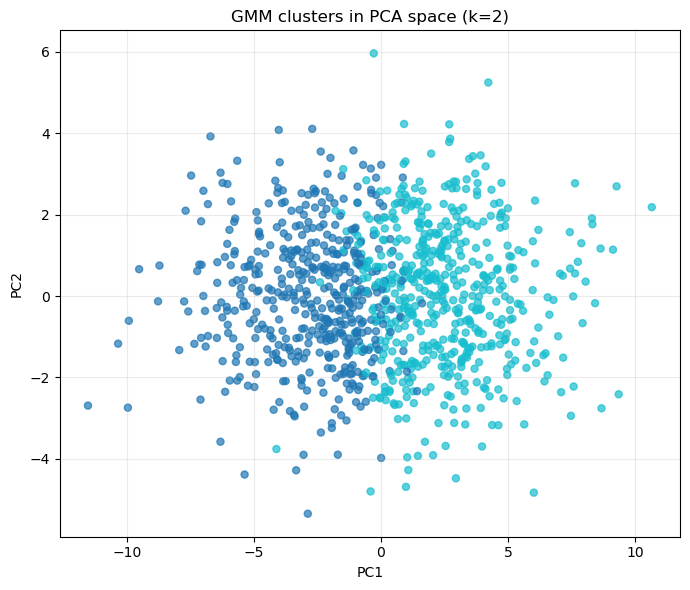

In [25]:

if N_COMPONENTS >= 2:
    plt.figure(figsize=(7, 6))
    plt.scatter(
        pca_scores["PC1"],
        pca_scores["PC2"],
        c=pca_scores["GMM_regime"],
        s=26,
        alpha=0.7,
        cmap="tab10",
    )
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(f"GMM clusters in PCA space (k={best_gmm_k})")
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()
else:
    print("At least two PCs are required for this plot.")



## 26. Save useful outputs

The output files make it easier to analyse the discovered clusters in a later notebook without repeating the complete PCA workflow.


In [26]:

if SAVE_OUTPUTS:
    OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)

    returns.to_csv(OUTPUT_DIRECTORY / "simple_returns.csv")
    scaled_returns.to_csv(OUTPUT_DIRECTORY / "standardised_returns.csv")
    variance_table.to_csv(
        OUTPUT_DIRECTORY / "pca_explained_variance.csv",
        index=False,
    )
    pca_scores.to_csv(OUTPUT_DIRECTORY / "pca_scores_and_regimes.csv")
    loadings.to_csv(OUTPUT_DIRECTORY / "pca_loadings.csv")
    market_features.to_csv(OUTPUT_DIRECTORY / "market_features_and_regimes.csv")
    kmeans_results.to_csv(
        OUTPUT_DIRECTORY / "kmeans_model_comparison.csv",
        index=False,
    )
    gmm_results.to_csv(
        OUTPUT_DIRECTORY / "gmm_model_comparison.csv",
        index=False,
    )
    selected_model_comparison.to_csv(
        OUTPUT_DIRECTORY / "selected_model_comparison.csv",
        index=False,
    )

    configuration_summary = pd.Series({
        "data_path": str(data_path),
        "return_type": RETURN_TYPE,
        "variance_target": VARIANCE_TARGET,
        "n_components_override": N_COMPONENTS_OVERRIDE,
        "n_components_used": N_COMPONENTS,
        "variance_retained": variance_retained,
        "whiten_pcs": WHITEN_PCS,
        "best_kmeans_k": best_kmeans_k,
        "best_gmm_k": best_gmm_k,
        "bayesian_effective_components": effective_components,
        "random_state": RANDOM_STATE,
    })

    configuration_summary.to_csv(
        OUTPUT_DIRECTORY / "configuration_summary.csv",
        header=["value"],
    )

    print(f"Outputs saved to: {OUTPUT_DIRECTORY.resolve()}")
else:
    print("SAVE_OUTPUTS is False, so no files were written.")


Outputs saved to: /Users/akhilmathur/Documents/Projects/susquehenna_algothon_TeamLynfield/Akhil_EDA/outputs/notebook1_market_pca



# How to judge the result

Do **not** conclude that genuine regimes exist merely because the algorithms return coloured clusters. Focus on:

1. **Explained variance:** Is \(k_{98}\) still a meaningful reduction from 51 assets?
2. **Separation:** Are silhouette scores clearly positive and reasonably stable across cluster counts?
3. **Persistence:** Do labels last for multiple consecutive periods, or switch almost every period?
4. **Repetition:** Does each state appear in several separated parts of the sample?
5. **Interpretation:** Do clusters clearly differ in return, volatility, dispersion or market breadth?
6. **Agreement:** Do K-means, GMM and Bayesian GMM identify broadly similar market states?
7. **Future testing:** Do the same structures persist under chronological train/test analysis?

## Main adjustment point

To change how many principal components all later cells use, edit only:

```python
N_COMPONENTS_OVERRIDE = None
```

- `None` means use \(k_{98}\)
- `12` means use exactly 12 PCs
- another positive integer uses that many PCs
